# Introduction

We are going to use 4 different approaches and finally compare the results of all of them:
1. Min-Max normalization
2. Zero-Mean normalization
3. Crossvalidation
4. Dimensionality reduction

# Data Preparation
This [dataset](https://www.kaggle.com/datasets/rabieelkharoua/air-quality-and-health-impact-dataset) contains comprehensive information on the air quality and its impact on public health for 5,811 records. It includes variables such as air quality index (AQI), concentrations of various pollutants, weather conditions, and health impact metrics. The target variable is the health impact class, which categorizes the health impact based on the air quality and other related factors.

This dataset offers a comprehensive view of the relationship between air quality and public health, making it ideal for research, predictive modeling, and statistical analysis.

In [1]:
include("utils/utils.jl")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


Retrieving notices: done
Channels:
 - anaconda
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/pablo/.julia/conda/3/x86_64

  added / updated specs:
    - conda


The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            conda-forge/noarch::certifi-2024.8.30~ --> anaconda/linux-64::certifi-2024.8.30-py312h06a4308_0 



Preparing transaction: done
Verifying transaction: done
Executing transaction: done
Channels:
 - conda-forge
 - bioconda
 - defaults
 - anaconda
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/pablo/.julia/conda/3/x86_64

  added / updated specs:
    - libstdcxx-ng[version='>=3.4,<13.0']


The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            anaconda/linux-64::certifi-2024.8.30-~ --> conda-forge/noarch::certifi-2024.8.30-pyhd8ed1ab_0 


┌ Info: Running `conda install -y -c anaconda conda` in root environment
└ @ Conda /home/pablo/.julia/packages/Conda/zReqD/src/Conda.jl:181
┌ Info: Running `conda install -y -c conda-forge 'libstdcxx-ng>=3.4,<13.0'` in root environment
└ @ Conda /home/pablo/.julia/packages/Conda/zReqD/src/Conda.jl:181


averageAccuracies (generic function with 1 method)

In [2]:
using CSV, DataFrames

# Load the dataset from the 'dataset' folder
data = CSV.read("datasets/air_quality_health_impact_data.csv", DataFrame)

# Check the dataset
describe(data)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,RecordID,2906.0,1,2906.0,5811,0,Int64
2,AQI,248.438,0.00581738,249.128,499.859,0,Float64
3,PM10,148.655,0.0158481,147.635,299.902,0,Float64
4,PM2_5,100.224,0.0315489,100.506,199.985,0,Float64
5,NO2,102.293,0.00962478,102.988,199.98,0,Float64
6,SO2,49.4568,0.0110232,49.5302,99.9696,0,Float64
7,O3,149.312,0.001661,149.56,299.937,0,Float64
8,Temperature,14.9755,-9.991,14.9424,39.9634,0,Float64
9,Humidity,54.7769,10.0015,54.5439,99.9975,0,Float64


We check how many classes have of each kind and plot the distribution

In [3]:
# Count elements in each class
counts = combine(groupby(data, :HealthImpactClass), nrow => :Count)

println("Elements per class:")
println(counts)

Elements per class:
5×2 DataFrame
 Row │ HealthImpactClass  Count 
     │ Float64            Int64 
─────┼──────────────────────────
   1 │               0.0   4808
   2 │               1.0    579
   3 │               2.0    273
   4 │               3.0     95
   5 │               4.0     56


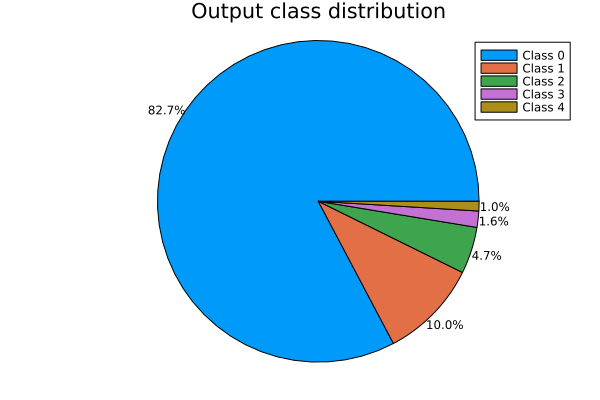

In [4]:
using Plots, Printf

cnt = counts.Count
labels = ["Class $i" for i in 0:4]
tot = sum(cnt)
datapct = [@sprintf("%.1f%%", x/tot*100) for x in cnt]

θ = (cumsum(cnt) - cnt/2) .* 360/sum(cnt)
scθ = sincosd.(θ)

p = pie(labels, cnt, title="Output class distribution")
for (s, sci) in zip(datapct, scθ)
    annotate!(1.1*sci[2], 1.1*sci[1], text(s, 8, :black))
end
p

Segmentation of the data on inputs and outputs

In [5]:
input_data = Matrix(data[!, 1:13]);
output_data = Int.(data[!, 15]);

@assert input_data isa Matrix
@assert output_data isa Vector{Int64}

To split the test from train we use the holdOut function with a fraction of 0.2. This means that 20% of the train data will be used for testing and the remaining 80% will be used for training.

In [6]:
# Split in train and test
(tr_idx, test_idx) = holdOutStratified(output_data, 0.2)

train_input = input_data[tr_idx,:]
train_output = output_data[tr_idx]
test_input = input_data[test_idx,:]
test_output = output_data[test_idx]

train_output = collect(train_output)
test_output = collect(test_output)

println("Train Input Size: ", size(train_input))
println("Train Output Size: ", size(train_output), " Categories:", sort(unique(train_output)))
println("Test Input Size: ", size(test_input))
println("Test Output Size: ", size(test_output), " Categories:", sort(unique(test_output)))

Train Input Size: (4648, 13)
Train Output Size: (4648,) Categories:[0, 1, 2, 3, 4]
Test Input Size: (1163, 13)
Test Output Size: (1163,) Categories:[0, 1, 2, 3, 4]


And we check if we have a repressentation of all the output classes in both groups (train and test)

In [7]:
columna = train_output[:, 1]

conteo = Dict(c => count(==(c), columna) for c in 0:4)

println("Elements per class:")
println(conteo)

Elements per class:
Dict(0 => 3846, 4 => 45, 2 => 218, 3 => 76, 1 => 463)


In [8]:
columna = test_output[:, 1]

conteo = Dict(c => count(==(c), columna) for c in 0:4)

println("Elements per class:")
println(conteo)

Elements per class:
Dict(0 => 962, 4 => 11, 2 => 55, 3 => 19, 1 => 116)


We will store the results of each approach in a DataFrame for easy ploting

In [9]:
metric_names = [:approach, :accuracy, :error_rate, :recall, :specificity, :ppv, :npv, :f_score]
metric_types = [String[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[]]
metrics = DataFrame(metric_types, metric_names)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64


# Definition of Models and Hyperparameters

We create a dictionary to store all hyperparameters of the different models. And also another DataFrame to store the accuracies obtained in the evaluation of each model.

In [10]:
## These are the modelsHyperParameters to be used in the models training

modelsHyperParameters = [
    # ANN configurations
    Dict("estimator" => :ANN, "topology" => (64,), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_64"),
    Dict("estimator" => :ANN, "topology" => (128,), "maxEpochs" => 500, "learningRate" => 0.005, "name" => "ANN_128"),
    Dict("estimator" => :ANN, "topology" => (64, 32), "maxEpochs" => 400, "learningRate" => 0.001, "name" => "ANN_64_32"),
    Dict("estimator" => :ANN, "topology" => (128, 64), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_128_64"),
    Dict("estimator" => :ANN, "topology" => (256,), "maxEpochs" => 300, "learningRate" => 0.05, "name" => "ANN_256"),
    Dict("estimator" => :ANN, "topology" => (128, 64, 32), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_128_64_32"),
    Dict("estimator" => :ANN, "topology" => (64, 64), "maxEpochs" => 250, "learningRate" => 0.005, "name" => "ANN_64_64"),
    Dict("estimator" => :ANN, "topology" => (256, 128), "maxEpochs" => 200, "learningRate" => 0.001, "name" => "ANN_256_128"),

    # SVM configurations
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.5, "degree"=>2, "name" => "SVM_rbf_05"),
    Dict("estimator" => :SVM, "kernel" => "linear", "C" => 1.0, "degree"=>4, "name" => "SVM_linear_1"),
    Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 0.01 , "degree" => 2, "name" => "SVM_poly_001"),
    Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 1.0, "degree" => 3, "name" => "SVM_sigmoid_1"),
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.01, "degree" => 3, "name" => "SVM_rbf_001"),
    Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 5, "degree" => 3, "name" => "SVM_poly_5"),
    Dict("estimator" => :SVM, "kernel" => "linear", "C"=> 0.5, "degree" => 3, "name" => "SVM_linear_05"),
    Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 10.0, "degree" => 5, "name" => "SVM_sigmoid_10"),

    # Decision Tree configurations
    Dict("estimator" => :DecisionTree, "max_depth" => 3, "random_state" => 42, "name" => "DT_3"),
    Dict("estimator" => :DecisionTree, "max_depth" => 5, "random_state" => 42, "name" => "DT_5"),
    Dict("estimator" => :DecisionTree, "max_depth" => 7, "random_state" => 42, "name" => "DT_7"),
    Dict("estimator" => :DecisionTree, "max_depth" => 11, "random_state" => 42, "name" => "DT_11"),
    Dict("estimator" => :DecisionTree, "max_depth" => 15, "random_state" => 42, "name" => "DT_15"),
    Dict("estimator" => :DecisionTree, "max_depth" => 21, "random_state" => 42, "name" => "DT_21"),

    # kNN configurations
    Dict("estimator" => :KNN, "k" => 3, "name" => "KNN_3"),
    Dict("estimator" => :KNN, "k" => 5, "name" => "KNN_5"),
    Dict("estimator" => :KNN, "k" => 7, "name" => "KNN_7"),
    Dict("estimator" => :KNN, "k" => 9, "name" => "KNN_9"),
    Dict("estimator" => :KNN, "k" => 11, "name" => "KNN_11"),
    Dict("estimator" => :KNN, "k" => 15, "name" => "KNN_15")
]

models_accuracies = DataFrame(Model = String[], MinMax = Float64[])
for m in modelsHyperParameters
    push!(models_accuracies, (m["name"], 0))
end


----
----

# 1. First approach: Using Min-Max Normalization.

In this approach we will use the Min-Max Normalization technique to normalize the data. And then, train all the models to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [11]:
train_input_minmax, test_input_minmax = normalizeData(train_input, test_input, :MinMax)

([0.7680785123966942 0.9968076970984374 … 0.21428571428571427 0.3333333333333333; 0.06835399449035813 0.7510802216816106 … 0.5 0.16666666666666666; … ; 0.013085399449035813 0.07405478623248905 … 0.35714285714285715 0.08333333333333333; 0.4762396694214876 0.2419527841534384 … 0.2857142857142857 0.25], [0.01050275482093664 0.8289695595062272 … 0.42857142857142855 0.08333333333333333; 0.26239669421487605 0.2568404341565256 … 0.35714285714285715 0.25; … ; 0.053546831955922865 0.025346559571983215 … 0.7142857142857143 0.25; 0.44300964187327824 0.22608382299341112 … 0.14285714285714285 0.0])

In this approach we wont use crossValidation, so we will train the models on the whole dataset and then evaluate them on the test set.

Pre-normalization data characteristics:

In [12]:
describe(DataFrame(train_input, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,2894.18,2.0,2883.5,5810.0,0,Float64
2,AQI,248.106,0.00581738,247.842,499.859,0,Float64
3,PM10,148.695,0.0722624,146.633,299.902,0,Float64
4,PM2_5,100.255,0.0315489,100.041,199.985,0,Float64
5,NO2,102.55,0.00962478,103.457,199.98,0,Float64
6,SO2,49.5244,0.0110232,49.8308,99.9598,0,Float64
7,O3,150.192,0.001661,150.699,299.937,0,Float64
8,Temperature,14.9606,-9.97026,14.9108,39.962,0,Float64
9,Humidity,54.7516,10.0015,54.3313,99.9975,0,Float64


Post-normalization data with min-max:

In [13]:
describe(DataFrame(train_input_minmax, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.497964,0.0,0.496126,1.0,0,Float64
2,AQI,0.496346,0.0,0.495818,1.0,0,Float64
3,PM10,0.495692,0.0,0.488815,1.0,0,Float64
4,PM2_5,0.501233,0.0,0.500165,1.0,0,Float64
5,NO2,0.512778,0.0,0.517313,1.0,0,Float64
6,SO2,0.495387,0.0,0.498453,1.0,0,Float64
7,O3,0.500744,0.0,0.502433,1.0,0,Float64
8,Temperature,0.499294,0.0,0.498297,1.0,0,Float64
9,Humidity,0.497245,0.0,0.492575,1.0,0,Float64


Training of the models and store the accuracies for final comparation.

In [14]:
accuracies = []
models = []
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = deepcopy(genModel(modelHyperParameters))
    fit!(model, train_input_minmax, train_output)
    acc = score(model, test_input_minmax, test_output)
    push!(accuracies, (idx, modelHyperParameters["estimator"], acc))
    push!(models, deepcopy(model))
    models_accuracies[models_accuracies.Model.==modelHyperParameters["name"], "MinMax"] .= acc
end;

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Once we have the accuracies, we will take the best of each model to create the ensemble, in this case we will create a stack, and then train the stack.

In [15]:
#println(accuracies)
best_models_position = best_model_positions(accuracies)

stacking_classifier = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models[idx]) for idx in best_models_position],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier, train_input_minmax, train_output)

PyObject StackingClassifier(estimators=[('m25_KNN', KNeighborsClassifier(n_neighbors=7)),
                               ('m10_SVM', SVC(degree=4, kernel='linear')),
                               ('m6_ANN',
                                MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                              learning_rate_init=0.01)),
                               ('m20_DecisionTree',
                                DecisionTreeClassifier(max_depth=11,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

Now we get the metrics of the stack ensemble.

In [16]:
outputs = stacking_classifier.predict(test_input_minmax)
categories = sort(unique(output_data))

x = copy(outputs)
y = vec(copy(test_output))

cm = confusionMatrix(x, y)
metrics_minmax = [
    "MinMax",
    cm["accuracy"],
    cm["error_rate"],
    cm["sensitivity"],
    cm["specificity"],
    cm["positive_predictive_value"],
    cm["negative_predictive_value"],
    cm["f_score"]
]
push!(metrics, metrics_minmax)


Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.932072,0.0679278,2.98733,4.76454,4.33027,4.82036,3.0995


And print the metrics and confusion matrix for this First Approach:

In [17]:
# Display results
println("METRICS 1st APPROACH (Min-Max Normalization):")
println("---------------------")
println("Accuracy: ", cm["accuracy"])
println("Error Rate: ", cm["error_rate"])
println("Sensitivity (Recall): ", cm["sensitivity"])
println("Specificity: ", cm["specificity"])
println("Precision: ", cm["positive_predictive_value"])
println("Negative Predictive Value: ", cm["negative_predictive_value"])
println("F-Score: ", cm["f_score"])
println("----------------------")
println()

print_confusion_matrix(cm["confusion_matrix"], ["Class $i" for i in 0:4])

METRICS 1st APPROACH (Min-Max Normalization):
---------------------
Accuracy: 0.9320722269991402
Error Rate: 0.06792777300085984
Sensitivity (Recall): 2.9873271771638374
Specificity: 4.764538702276839
Precision: 4.330266412028823
Negative Predictive Value: 4.820355512905946
F-Score: 3.0995032313227284
----------------------

CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       938        23         1         0         0
   Class 1        12        96         8         0         0
   Class 2        10         1        42         2         0
   Class 3         9         0         2         8         0
   Class 4         9         1         1         0         0


----
----

# 2. Second Approach: Using Standard normalization

In this approach we will use the Zero-Mean Normalization technique to normalize the data. And then, train the models to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [18]:
train_input_zm, test_input_zm = normalizeData(train_input, test_input, :MinMax)

([0.7680785123966942 0.9968076970984374 … 0.21428571428571427 0.3333333333333333; 0.06835399449035813 0.7510802216816106 … 0.5 0.16666666666666666; … ; 0.013085399449035813 0.07405478623248905 … 0.35714285714285715 0.08333333333333333; 0.4762396694214876 0.2419527841534384 … 0.2857142857142857 0.25], [0.01050275482093664 0.8289695595062272 … 0.42857142857142855 0.08333333333333333; 0.26239669421487605 0.2568404341565256 … 0.35714285714285715 0.25; … ; 0.053546831955922865 0.025346559571983215 … 0.7142857142857143 0.25; 0.44300964187327824 0.22608382299341112 … 0.14285714285714285 0.0])

Post-normalization data with zero-mean:

In [19]:
describe(DataFrame(train_input_zm, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.497964,0.0,0.496126,1.0,0,Float64
2,AQI,0.496346,0.0,0.495818,1.0,0,Float64
3,PM10,0.495692,0.0,0.488815,1.0,0,Float64
4,PM2_5,0.501233,0.0,0.500165,1.0,0,Float64
5,NO2,0.512778,0.0,0.517313,1.0,0,Float64
6,SO2,0.495387,0.0,0.498453,1.0,0,Float64
7,O3,0.500744,0.0,0.502433,1.0,0,Float64
8,Temperature,0.499294,0.0,0.498297,1.0,0,Float64
9,Humidity,0.497245,0.0,0.492575,1.0,0,Float64


In [20]:
accuracies = []
models = []
models_accuracies[!, :ZeroMean] .= 0.0
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = genModel(modelHyperParameters)
    fit!(model, train_input_zm, train_output)
    acc = score(model, test_input_zm, test_output)
    push!(accuracies, (idx, modelHyperParameters["estimator"], acc))
    push!(models, deepcopy(model))
    models_accuracies[models_accuracies.Model.==modelHyperParameters["name"], "ZeroMean"] .= acc
end;

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [21]:
#println(accuracies)
best_models_position = best_model_positions(accuracies)

stacking_classifier = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models[idx]) for idx in best_models_position],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier, train_input_zm, train_output)

PyObject StackingClassifier(estimators=[('m25_KNN', KNeighborsClassifier(n_neighbors=7)),
                               ('m10_SVM', SVC(degree=4, kernel='linear')),
                               ('m4_ANN',
                                MLPClassifier(hidden_layer_sizes=(128, 64),
                                              learning_rate_init=0.01)),
                               ('m20_DecisionTree',
                                DecisionTreeClassifier(max_depth=11,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

In [22]:
outputs = stacking_classifier.predict(test_input_zm)
categories = sort(unique(output_data))

x = copy(outputs)
y = vec(copy(test_output))

cm = confusionMatrix(x, y)
metrics_zm = [
    "ZeroMean",
    cm["accuracy"],
    cm["error_rate"],
    cm["sensitivity"],
    cm["specificity"],
    cm["positive_predictive_value"],
    cm["negative_predictive_value"],
    cm["f_score"]
]
push!(metrics, metrics_zm)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.932072,0.0679278,2.98733,4.76454,4.33027,4.82036,3.0995
2,ZeroMean,0.940671,0.0593293,2.62685,4.7661,4.58927,4.89265,2.60523


In [23]:
# Display results
println("METRICS 2nd APPROACH (Zero-Mean Normalization):")
println("---------------------")
println("Accuracy: ", cm["accuracy"])
println("Error Rate: ", cm["error_rate"])
println("Sensitivity (Recall): ", cm["sensitivity"])
println("Specificity: ", cm["specificity"])
println("Precision: ", cm["positive_predictive_value"])
println("Negative Predictive Value: ", cm["negative_predictive_value"])
println("F-Score: ", cm["f_score"])
println("----------------------")
println()

print_confusion_matrix(cm["confusion_matrix"], ["Class $i" for i in 0:4])

METRICS 2nd APPROACH (Zero-Mean Normalization):
---------------------
Accuracy: 0.94067067927773
Error Rate: 0.05932932072227004
Sensitivity (Recall): 2.6268513871962145
Specificity: 4.766098134692462
Precision: 4.5892704262051
Negative Predictive Value: 4.892650934469226
F-Score: 2.605228523503779
----------------------

CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       953         9         0         0         0
   Class 1        14        97         5         0         0
   Class 2        10         1        44         0         0
   Class 3         9         1         1         0         0
   Class 4         9         0        10         0         0


----
----

# 3. Third Approach: Using Crossvalidation

In this approach we will use the Crossvalidation technique to train the models, and using the normalization of the data that gave us the best results in the previous steps.

In [24]:
kFoldIndices = crossvalidation(size(train_output, 1), 5)

metrics_given = trainClassEnsemble(modelsHyperParameters,
                                    (train_input_minmax, train_output), 
                                    kFoldIndices)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Dict{String, Any} with 8 entries:
  "sensitivity"               => (2.67493, 0.147422)
  "positive_predictive_value" => (4.56662, 0.130909)
  "specificity"               => (4.7603, 0.0234197)
  "negative_predictive_value" => (4.89418, 0.0223933)
  "f_score"                   => (2.74838, 0.247478)
  "accuracy"                  => (0.939975, 0.00382062)
  "error_rate"                => (0.0600252, 0.00382062)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.934379)…

In [25]:
models_accuracies[!, :CrossVal] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :CrossVal] = m[3]
    i += 1
end

In [26]:
metrics_cv = [
    "CrossVal",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_cv)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.932072,0.0679278,2.98733,4.76454,4.33027,4.82036,3.0995
2,ZeroMean,0.940671,0.0593293,2.62685,4.7661,4.58927,4.89265,2.60523
3,CrossVal,0.939975,0.0600252,2.67493,4.7603,4.56662,4.89418,2.74838


In [27]:
# Display results
println("METRICS 3rd APPROACH (Cross-Validation):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 3rd APPROACH (Cross-Validation):
---------------------
Accuracy: 0.939974767642395
Error Rate: 0.060025232357605
Sensitivity (Recall): 2.6749344446614187
Specificity: 4.760302955941084
Precision: 4.566620582476803
Negative Predictive Value: 4.894175810481165
F-Score: 2.748380636940131
----------------------



----
----

# 4. Fourth Approach: dimensionality reduction

In this approach we will apply dimensionality reduction technique to reduce the dimension of the data. Specificaly we will use PCA (Principal Component Analysis) and then compare the results with the previous approaches.

In order to get the best dimension, first we tried to explore the dimension reducction from 12 to 3, one by one, in a loop. But it took more than 24 hours of execution in a commont laptop, so we had to discard this option. Instead, we decided to try two different dimensionality reductions, one with only 3 features, and the other one with reduction conservating the 95% of the representation. Then, we will take the best results to make that reduction and compare with the other approaches.

In [28]:
using ScikitLearn
@sk_import decomposition:PCA

PyObject <class 'sklearn.decomposition._pca.PCA'>

In [29]:
train_input_minmax, test_input_minmax = normalizeData(train_input, test_input, :MinMax)

([0.7680785123966942 0.9968076970984374 … 0.21428571428571427 0.3333333333333333; 0.06835399449035813 0.7510802216816106 … 0.5 0.16666666666666666; … ; 0.013085399449035813 0.07405478623248905 … 0.35714285714285715 0.08333333333333333; 0.4762396694214876 0.2419527841534384 … 0.2857142857142857 0.25], [0.01050275482093664 0.8289695595062272 … 0.42857142857142855 0.08333333333333333; 0.26239669421487605 0.2568404341565256 … 0.35714285714285715 0.25; … ; 0.053546831955922865 0.025346559571983215 … 0.7142857142857143 0.25; 0.44300964187327824 0.22608382299341112 … 0.14285714285714285 0.0])

## 4.a Reduction to 3 features

In [31]:
#Define the PCA object and the number of componentes that are desired
pca_3 = PCA(3)

#Ajust the matrix acording to the train data
fit!(pca_3, train_input_minmax)

#Once it is ajusted it can be used to transform the data
pca_train_3 = pca_3.transform(train_input_minmax)
pca_test_3 = pca_3.transform(test_input_minmax)

print("Train Patterns ", size(train_input_minmax), " -> ", size(pca_train_3))
print("Train Patterns ", size(test_input_minmax), " -> ", size(pca_test_3))

@assert (size(train_input_minmax)[1],3) == size(pca_train_3)
@assert (size(test_input_minmax)[1],3) == size(pca_test_3)

Train Patterns (4648, 13) -> (4648, 3)Train Patterns (1163, 13) -> (1163, 3)

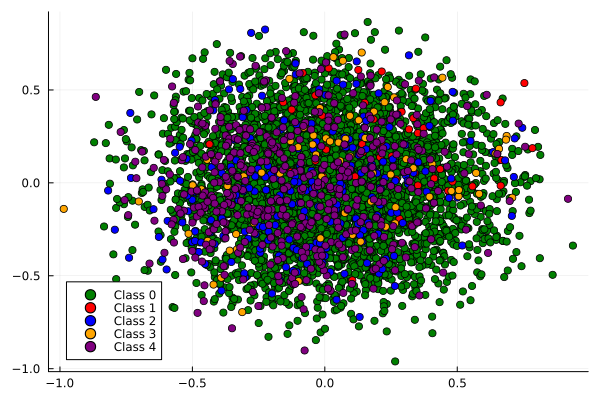

In [32]:
# one hot encoding only for graph
one_hot_train_output = oneHotEncoding(train_output)

colors = [:green, :red, :blue, :orange, :purple]
target_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

# Call the function
draw_results(pca_train_3, one_hot_train_output; colors=colors, target_names=target_names)

In [33]:
metrics_given = trainClassEnsemble(modelsHyperParameters,
                                    (pca_train_3, train_output),
                                    kFoldIndices)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Dict{String, Any} with 8 entries:
  "sensitivity"               => (1.0, 0.0)
  "positive_predictive_value" => (4.82745, 0.0165277)
  "specificity"               => (4.0, 0.0)
  "negative_predictive_value" => (4.82745, 0.0165277)
  "f_score"                   => (0.905506, 0.00986782)
  "accuracy"                  => (0.827448, 0.0165277)
  "error_rate"                => (0.172552, 0.0165277)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.827018)…

In [34]:
models_accuracies[!, :PCA_3] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :PCA_3] = m[3]
    i += 1
end

In [35]:
metrics_pca3 = [
    "PCA_3",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_pca3)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.932072,0.0679278,2.98733,4.76454,4.33027,4.82036,3.0995
2,ZeroMean,0.940671,0.0593293,2.62685,4.7661,4.58927,4.89265,2.60523
3,CrossVal,0.939975,0.0600252,2.67493,4.7603,4.56662,4.89418,2.74838
4,PCA_3,0.827448,0.172552,1.0,4.0,4.82745,4.82745,0.905506


In [36]:
# Display results
println("METRICS 4th APPROACH (PCA 3 dimensions):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 4th APPROACH (PCA 3 dimensions):
---------------------
Accuracy: 0.8274479437943448
Error Rate: 0.17255205620565528
Sensitivity (Recall): 1.0
Specificity: 4.0
Precision: 4.827447943794345
Negative Predictive Value: 4.827447943794345
F-Score: 0.905506186978356
----------------------



## 4.b: Reduction at 95% of the representation

In [37]:
## Apply a reduction conserving the 95% of the representation of the data
pca_95 = PCA(0.95)
fit!(pca_95, train_input_minmax)

#Once it is ajusted it can be used to transform the data
pca_train_95 = pca_95.transform(train_input_minmax)
pca_test_95 = pca_95.transform(test_input_minmax)

print("Train Patterns ", size(train_input_minmax), " -> ", size(pca_train_95))
print("Train Patterns ", size(test_input_minmax), " -> ", size(pca_test_95))

Train Patterns (4648, 13) -> (4648, 11)Train Patterns (1163, 13) -> (1163, 11)

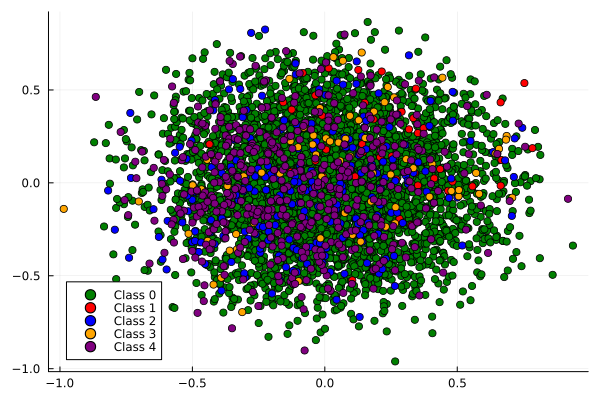

In [38]:
one_hot_train_output = oneHotEncoding(train_output)
colors = [:green, :red, :blue, :orange, :purple]
target_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

# Call the function
draw_results(pca_train_95, one_hot_train_output; colors=colors, target_names=target_names)

In [39]:
metrics_given = trainClassEnsemble(modelsHyperParameters,
    (pca_train_95, train_output),
    kFoldIndices)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Dict{String, Any} with 8 entries:
  "sensitivity"               => (2.50598, 0.147696)
  "positive_predictive_value" => (4.41965, 0.223136)
  "specificity"               => (4.7364, 0.0420801)
  "negative_predictive_value" => (4.89087, 0.0207856)
  "f_score"                   => (2.53905, 0.15215)
  "accuracy"                  => (0.934595, 0.00865529)
  "error_rate"                => (0.0654048, 0.00865529)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.927925)…

In [40]:
models_accuracies[!, :PCA_095] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :PCA_095] = m[3]
    i += 1
end

In [41]:
metrics_pca95 = [
    "PCA_095",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_pca95)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.932072,0.0679278,2.98733,4.76454,4.33027,4.82036,3.0995
2,ZeroMean,0.940671,0.0593293,2.62685,4.7661,4.58927,4.89265,2.60523
3,CrossVal,0.939975,0.0600252,2.67493,4.7603,4.56662,4.89418,2.74838
4,PCA_3,0.827448,0.172552,1.0,4.0,4.82745,4.82745,0.905506
5,PCA_095,0.934595,0.0654048,2.50598,4.7364,4.41965,4.89087,2.53905


In [42]:
# Display results
println("METRICS 4th APPROACH (PCA 0.95 dimensions):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 4th APPROACH (PCA 0.95 dimensions):
---------------------
Accuracy: 0.9345951827031032
Error Rate: 0.06540481729689687
Sensitivity (Recall): 2.5059816463478564
Specificity: 4.736398083039864
Precision: 4.419647312917286
Negative Predictive Value: 4.8908683677068865
F-Score: 2.539047908093784
----------------------



# Results

In [43]:
println(metrics)

5×8 DataFrame
 Row │ approach  accuracy  error_rate  recall   specificity  ppv      npv      f_score  
     │ String    Float64   Float64     Float64  Float64      Float64  Float64  Float64  
─────┼──────────────────────────────────────────────────────────────────────────────────
   1 │ MinMax    0.932072   0.0679278  2.98733      4.76454  4.33027  4.82036  3.0995
   2 │ ZeroMean  0.940671   0.0593293  2.62685      4.7661   4.58927  4.89265  2.60523
   3 │ CrossVal  0.939975   0.0600252  2.67493      4.7603   4.56662  4.89418  2.74838
   4 │ PCA_3     0.827448   0.172552   1.0          4.0      4.82745  4.82745  0.905506
   5 │ PCA_095   0.934595   0.0654048  2.50598      4.7364   4.41965  4.89087  2.53905


In [44]:
println(models_accuracies)

28×6 DataFrame
 Row │ Model           MinMax    ZeroMean  CrossVal  PCA_3     PCA_095  
     │ String          Float64   Float64   Float64   Float64   Float64  
─────┼──────────────────────────────────────────────────────────────────
   1 │ ANN_64          0.935512  0.94239   0.934379  0.827018  0.927925
   2 │ ANN_128         0.939811  0.912296  0.929001  0.826802  0.921687
   3 │ ANN_64_32       0.941531  0.934652  0.938252  0.827233  0.934382
   4 │ ANN_128_64      0.932932  0.950989  0.932662  0.823789  0.928571
   5 │ ANN_256         0.924334  0.941531  0.93395   0.826802  0.92104
   6 │ ANN_128_64_32   0.94497   0.935512  0.936746  0.813678  0.92771
   7 │ ANN_64_64       0.937231  0.934652  0.932014  0.824005  0.931581
   8 │ ANN_256_128     0.932932  0.935512  0.93352   0.826588  0.933733
   9 │ SVM_rbf_05      0.88822   0.88822   0.882958  0.827448  0.883174
  10 │ SVM_linear_1    0.899398  0.899398  0.904043  0.827448  0.904043
  11 │ SVM_poly_001    0.827171  0.827171  0.827

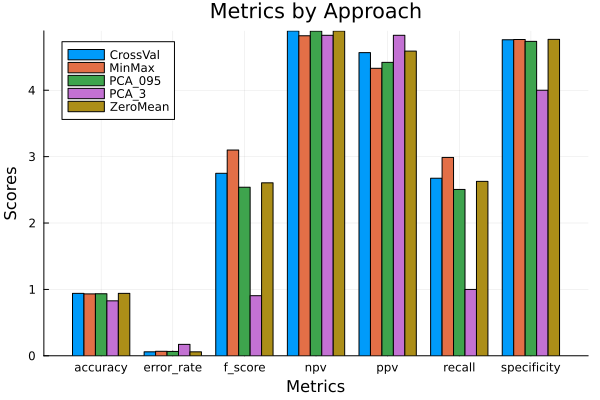

In [45]:
using StatsPlots

df = copy(metrics)

ctg = repeat(["MinMax", "ZeroMean", "CrossVal", "PCA_3", "PCA_095"], inner=7)
nam = repeat(names(df)[2:8], outer=5)
mm = collect(df[1,2:8])
zm = collect(df[2,2:8])
cv = collect(df[3,2:8])
pca3 = collect(df[4,2:8])
pca95 = collect(df[5,2:8])

groupedbar(nam, [mm zm cv pca3 pca95], group = ctg, xlabel = "Metrics", ylabel = "Scores",
           title = "Metrics by Approach")

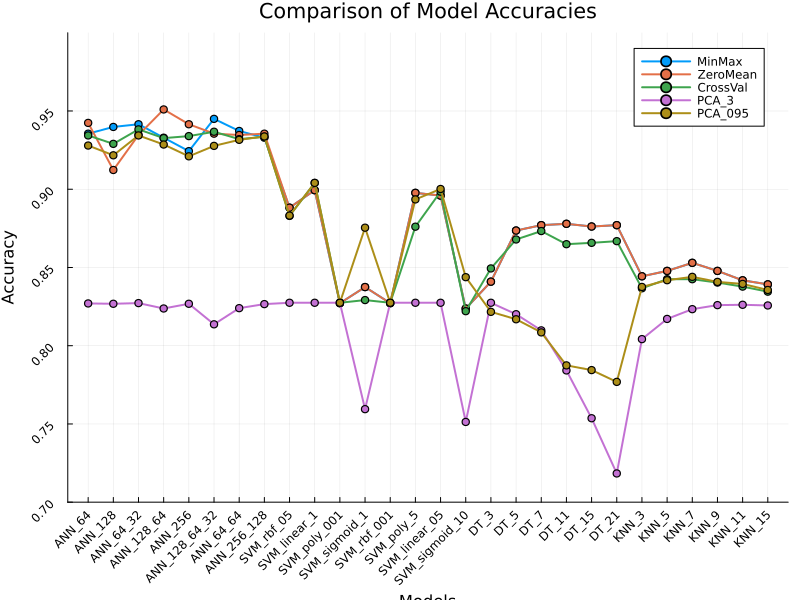

In [46]:
using Plots

df = copy(models_accuracies)

p = plot(
    1:nrow(df), 
    Matrix(df[:, 2:end]),
    label = permutedims(names(df)[2:end]),
    title = "Comparison of Model Accuracies",
    xlabel = "Models",
    ylabel = "Accuracy",
    legend = :topright,
    size = (800, 600),
    lw = 2,
    marker = :circle,
    markersize = 4
)
xticks!(1:nrow(df), df.Model, rotation = 45)
ylims!(0.7, 1.0)